In [1]:
import cv2
from ultralytics import YOLO
import os

from sahi import AutoDetectionModel
from sahi.predict import get_prediction
from sahi.utils.cv import read_image

from sahi.predict import get_sliced_prediction

import matplotlib.pyplot as plt
import numpy as np

In [2]:
model = YOLO("yolo12x.pt")

In [3]:
images = [os.path.join("../data/motorbike_trial/val/images", f) for f in os.listdir("../data/motorbike_trial/val/images") if f.endswith(('.png', '.jpg', '.jpeg'))]
labels = [os.path.join("../data/motorbike_trial/val/labels", f) for f in os.listdir("../data/motorbike_trial/val/labels") if f.endswith('.npy')]

In [4]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="yolo12x.pt",
    confidence_threshold=0.3,
    device="cuda:0",
)

In [ ]:
result = get_sliced_prediction(
    "../data/motorbike_trial/val/images/1109.jpg",
    detection_model,
    slice_height=64,
    slice_width=64,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    exclude_classes_by_id=list(range(1,80))
)

Performing prediction on 60 slices.


In [2]:
def visualize_gt(image_path, npy_path, ax=None):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    points = np.load(npy_path, allow_pickle=True)
    
    for point in points:
        x, y = int(point[0]), int(point[1]) 
        cv2.circle(img, (x, y), 4, (0, 255, 0), -1)

    if ax is None:
        print(f"GT count: {len(points)}")
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    else:
        ax.imshow(img)
        ax.set_title(f"Ground Truth: {len(points)}")
        ax.axis('off')

def pred_img_show(image_path, result, ax=None):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if img is None:
        print(f"Can't find image's path: '{image_path}'")
        return

    for obj in result.object_prediction_list:
        x_min = int(obj.bbox.minx)
        y_min = int(obj.bbox.miny)
        x_max = int(obj.bbox.maxx)
        y_max = int(obj.bbox.maxy) 
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    
    if ax is None:
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    else:
        ax.imshow(img)
        ax.set_title(f"Prediction: {len(result.object_prediction_list)}")
        ax.axis('off')

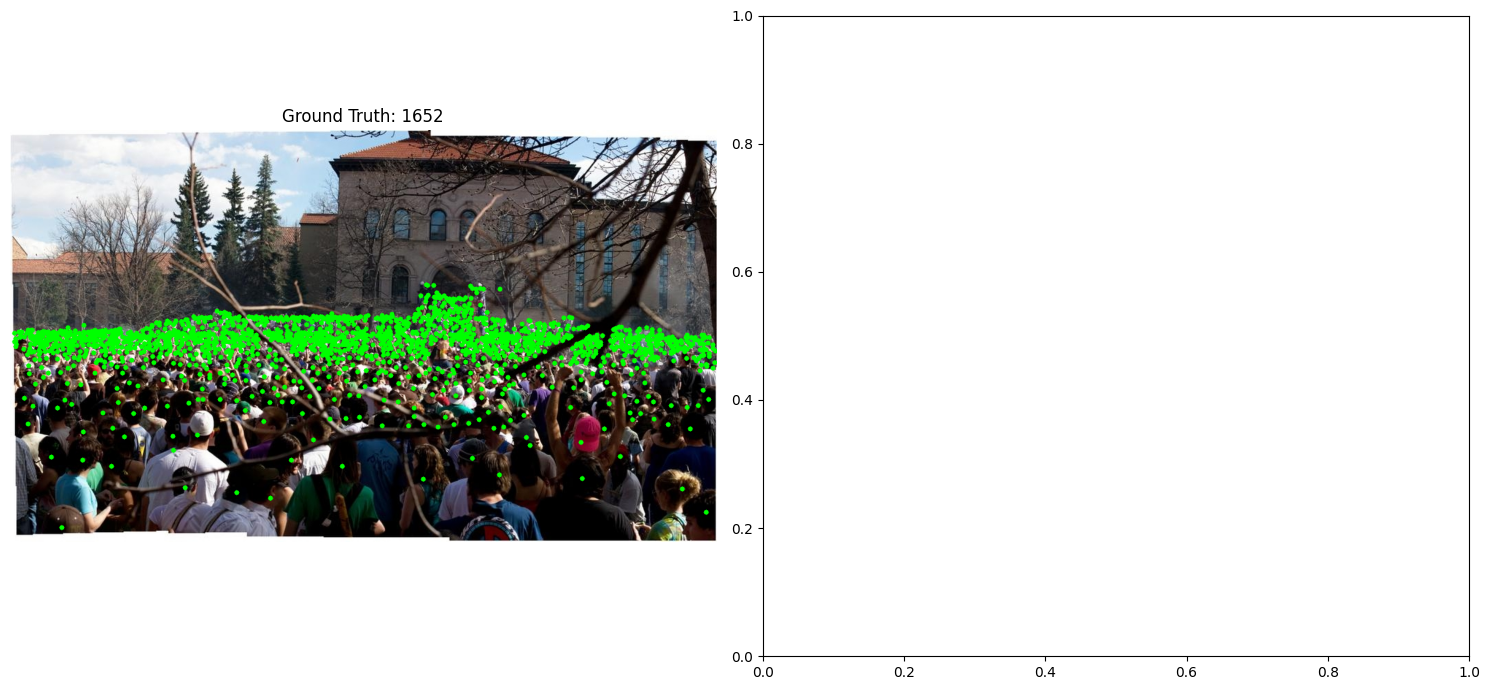

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

visualize_gt("../data/sha/train/images/007.jpg", "../data/sha/train/labels/007.npy", ax=ax1)
# pred_img_show("../data/motorbike_trial/val/images/1109.jpg", result, ax=ax2)

plt.tight_layout()
plt.show()

In [54]:
total_mae = 0
total_mse = 0

for idx in range(len(images)):
    result = get_sliced_prediction(
        images[idx],
        detection_model,
        slice_height=128,
        slice_width=128,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        exclude_classes_by_id=list(range(1,80)),
        verbose=0
    )
    pred_count = len(result.object_prediction_list)
    gt_points = np.load(labels[idx], allow_pickle=True)
    total_mae += abs(len(gt_points) - pred_count)
    total_mse += (len(gt_points) - pred_count) ** 2
    print(f"Image: {os.path.basename(images[idx])} | GT: {len(gt_points)} | Pred: {pred_count}")
final_mae = total_mae / len(images)
final_rmse = np.sqrt(total_mse / len(images))

print(f"MAE : {final_mae:.4f}")
print(f"RMSE: {final_rmse:.4f}")

Image: 001.jpg | GT: 172 | Pred: 56
Image: 002.jpg | GT: 1111 | Pred: 160
Image: 003.jpg | GT: 297 | Pred: 67
Image: 004.jpg | GT: 170 | Pred: 129
Image: 005.jpg | GT: 817 | Pred: 269
Image: 006.jpg | GT: 361 | Pred: 232
Image: 007.jpg | GT: 568 | Pred: 121
Image: 008.jpg | GT: 1326 | Pred: 69
Image: 009.jpg | GT: 371 | Pred: 96
Image: 010.jpg | GT: 502 | Pred: 208
Image: 011.jpg | GT: 1068 | Pred: 233
Image: 012.jpg | GT: 321 | Pred: 24
Image: 013.jpg | GT: 584 | Pred: 219
Image: 014.jpg | GT: 762 | Pred: 187
Image: 015.jpg | GT: 341 | Pred: 79
Image: 016.jpg | GT: 416 | Pred: 56
Image: 017.jpg | GT: 1156 | Pred: 250
Image: 018.jpg | GT: 227 | Pred: 54
Image: 019.jpg | GT: 230 | Pred: 61
Image: 020.jpg | GT: 460 | Pred: 353
Image: 021.jpg | GT: 717 | Pred: 106
Image: 022.jpg | GT: 212 | Pred: 31
Image: 023.jpg | GT: 429 | Pred: 90
Image: 024.jpg | GT: 553 | Pred: 244
Image: 025.jpg | GT: 243 | Pred: 86
Image: 026.jpg | GT: 497 | Pred: 80
Image: 027.jpg | GT: 760 | Pred: 140
Image: 028

In [5]:
images_b = [os.path.join("../data/shb/val/images", f) for f in os.listdir("../data/shb/val/images") if f.endswith(('.png', '.jpg', '.jpeg'))]
labels_b = [os.path.join("../data/shb/val/labels", f) for f in os.listdir("../data/shb/val/labels") if f.endswith('.npy')]

In [34]:
result = get_sliced_prediction(
    images_b[227],
    detection_model,
    slice_height=196,
    slice_width=196,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    exclude_classes_by_id=list(range(1,80))
)

Performing prediction on 35 slices.


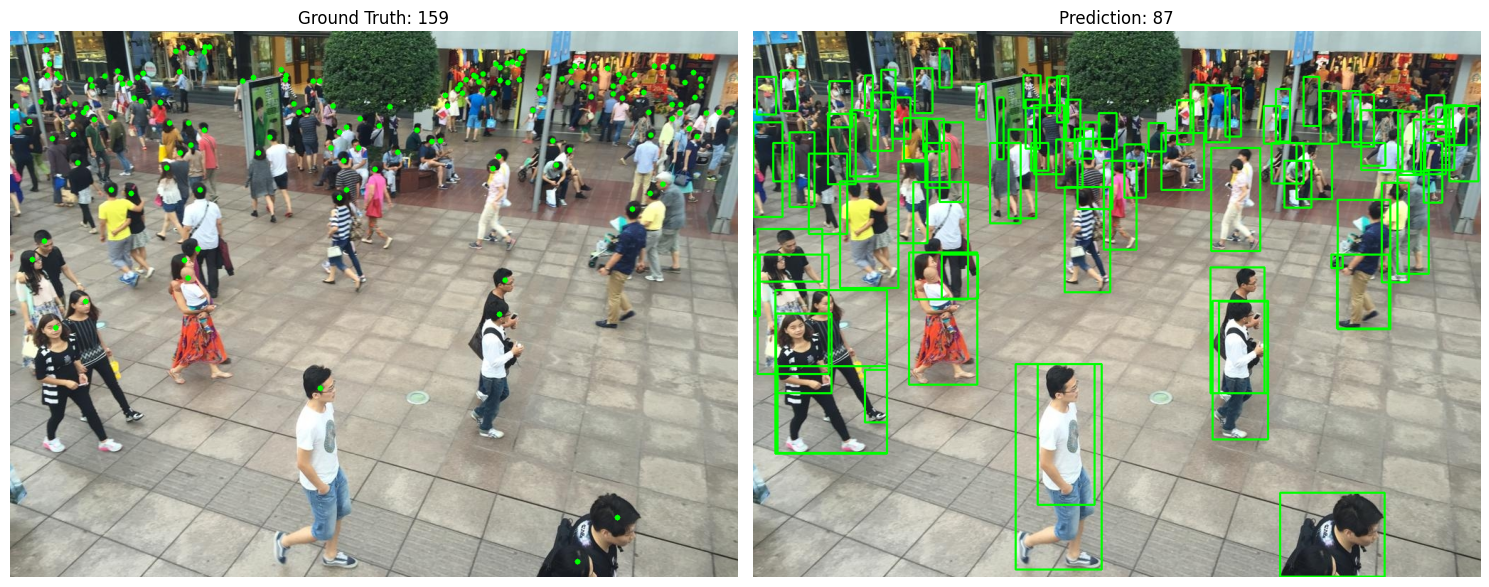

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

visualize_gt(images_b[227], labels_b[227], ax=ax1)
pred_img_show(images_b[227], result, ax=ax2)

plt.tight_layout()
plt.show()

In [36]:
total_mae = 0
total_mse = 0

for idx in range(len(images_b)):
    result = get_sliced_prediction(
        images_b[idx],
        detection_model,
        slice_height=196,
        slice_width=196,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        exclude_classes_by_id=list(range(1,80)),
        verbose=0
    )
    pred_count = len(result.object_prediction_list)
    gt_points = np.load(labels_b[idx], allow_pickle=True)
    total_mae += abs(len(gt_points) - pred_count)
    total_mse += (len(gt_points) - pred_count) ** 2
    print(f"Image: {os.path.basename(images_b[idx])} | GT: {len(gt_points)} | Pred: {pred_count}")
final_mae = total_mae / len(images_b)
final_rmse = np.sqrt(total_mse / len(images_b))

print(f"MAE : {final_mae:.4f}")
print(f"RMSE: {final_rmse:.4f}")

Image: 001.jpg | GT: 23 | Pred: 43
Image: 002.jpg | GT: 52 | Pred: 58
Image: 003.jpg | GT: 61 | Pred: 78
Image: 004.jpg | GT: 95 | Pred: 86
Image: 005.jpg | GT: 82 | Pred: 62
Image: 006.jpg | GT: 195 | Pred: 88
Image: 007.jpg | GT: 47 | Pred: 62
Image: 008.jpg | GT: 62 | Pred: 63
Image: 009.jpg | GT: 36 | Pred: 64
Image: 010.jpg | GT: 181 | Pred: 84
Image: 011.jpg | GT: 164 | Pred: 79
Image: 012.jpg | GT: 513 | Pred: 93
Image: 013.jpg | GT: 48 | Pred: 59
Image: 014.jpg | GT: 29 | Pred: 40
Image: 015.jpg | GT: 57 | Pred: 58
Image: 016.jpg | GT: 92 | Pred: 72
Image: 017.jpg | GT: 71 | Pred: 75
Image: 018.jpg | GT: 235 | Pred: 71
Image: 019.jpg | GT: 277 | Pred: 108
Image: 020.jpg | GT: 15 | Pred: 36
Image: 021.jpg | GT: 89 | Pred: 85
Image: 022.jpg | GT: 300 | Pred: 103
Image: 023.jpg | GT: 239 | Pred: 70
Image: 024.jpg | GT: 79 | Pred: 70
Image: 025.jpg | GT: 216 | Pred: 71
Image: 026.jpg | GT: 38 | Pred: 54
Image: 027.jpg | GT: 207 | Pred: 95
Image: 028.jpg | GT: 61 | Pred: 59
Image: 0